In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

housing = pd.read_csv("AmesHousing.csv")

housing.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [2]:
housing.info()


<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

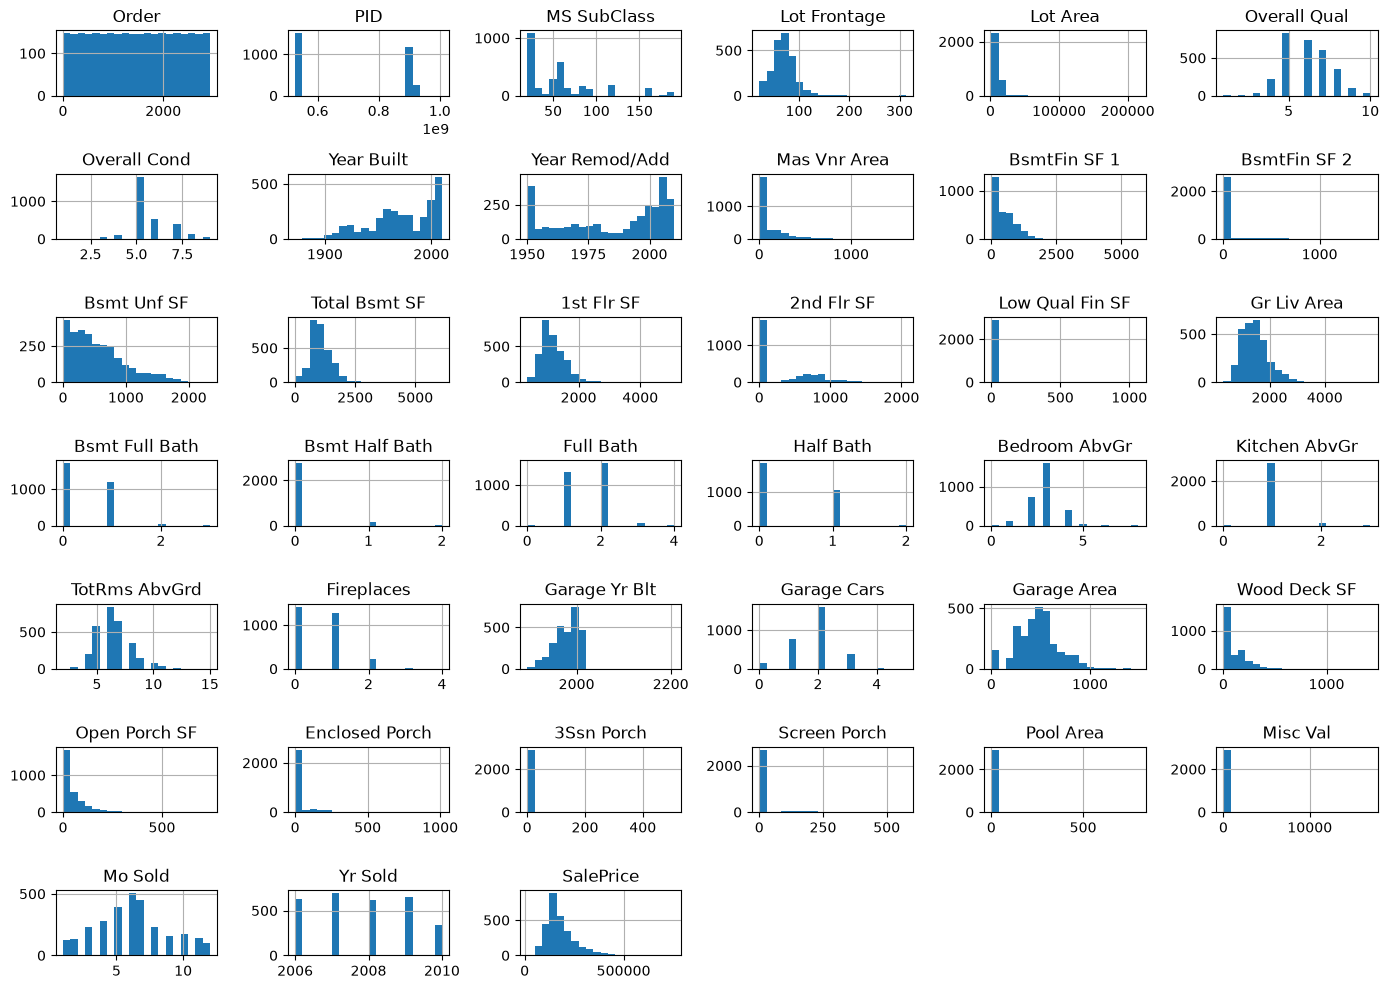

In [3]:
housing.hist(
    bins=20,
    figsize=(14, 10)
)

plt.tight_layout()
plt.show()

In [4]:
correlations = (
    housing.corr(numeric_only=True)["SalePrice"]
    .sort_values(ascending=False)
    .round(2)
)

correlations

SalePrice          1.00
Overall Qual       0.80
Gr Liv Area        0.71
Garage Cars        0.65
Garage Area        0.64
Total Bsmt SF      0.63
1st Flr SF         0.62
Year Built         0.56
Full Bath          0.55
Year Remod/Add     0.53
Garage Yr Blt      0.53
Mas Vnr Area       0.51
TotRms AbvGrd      0.50
Fireplaces         0.47
BsmtFin SF 1       0.43
Lot Frontage       0.36
Wood Deck SF       0.33
Open Porch SF      0.31
Half Bath          0.29
Bsmt Full Bath     0.28
2nd Flr SF         0.27
Lot Area           0.27
Bsmt Unf SF        0.18
Bedroom AbvGr      0.14
Screen Porch       0.11
Pool Area          0.07
Mo Sold            0.04
3Ssn Porch         0.03
BsmtFin SF 2       0.01
Misc Val          -0.02
Yr Sold           -0.03
Order             -0.03
Bsmt Half Bath    -0.04
Low Qual Fin SF   -0.04
MS SubClass       -0.09
Overall Cond      -0.10
Kitchen AbvGr     -0.12
Enclosed Porch    -0.13
PID               -0.25
Name: SalePrice, dtype: float64

highly correlated with the quality and the superficie of the house 

In [5]:
housing["Overall Qual"].value_counts()

Overall Qual
5     825
6     732
7     602
8     350
4     226
9     107
3      40
10     31
2      13
1       4
Name: count, dtype: int64

Overall quality is already divided as 10 groups we can use for the spliting of train / test data 

In [6]:
housing["SalePrice"].describe()


count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

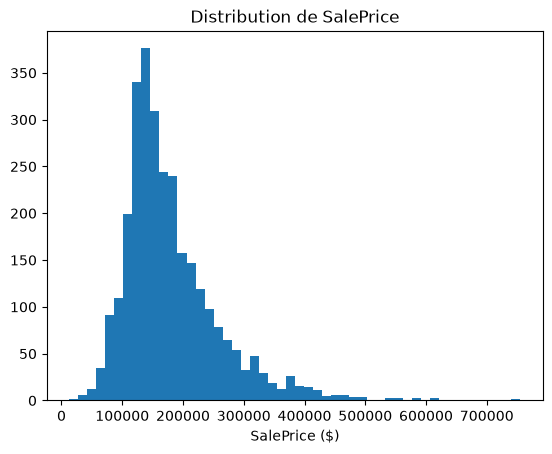

Skewness: 1.7435000757376466


In [7]:

plt.hist(housing["SalePrice"], bins=50)
plt.title("Distribution de SalePrice")
plt.xlabel("SalePrice ($)")
plt.show()

print("Skewness:", housing["SalePrice"].skew())

SalePrice est asymetrique a droite, quelques ventes tres cheres tirent la moyenne vers le haut

In [8]:
missing = housing.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(housing) * 100).round(1)

pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})

,n_missing,pct_missing
Pool QC,2917,99.6
Misc Feature,2824,96.4
Alley,2732,93.2
Fence,2358,80.5
Mas Vnr Type,1775,60.6
Fireplace Qu,1422,48.5
Lot Frontage,490,16.7
Garage Qual,159,5.4
Garage Cond,159,5.4
Garage Yr Blt,159,5.4


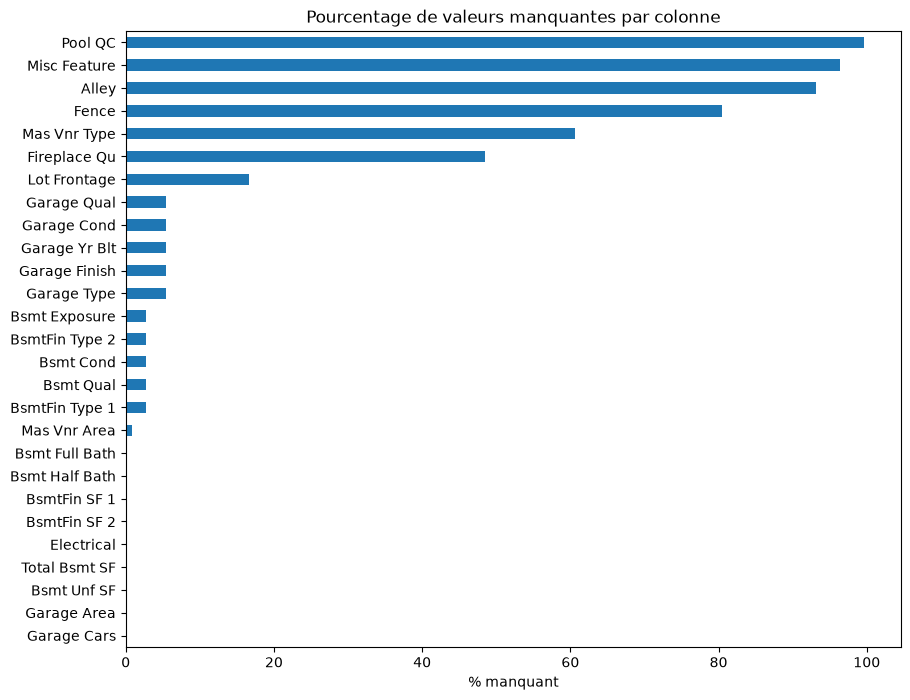

In [9]:
plt.figure(figsize=(10,8))
missing_pct.plot(kind="barh")
plt.title("Pourcentage de valeurs manquantes par colonne")
plt.xlabel("% manquant")
plt.gca().invert_yaxis()
plt.show()

diagram of the missing values mainly on categorical values

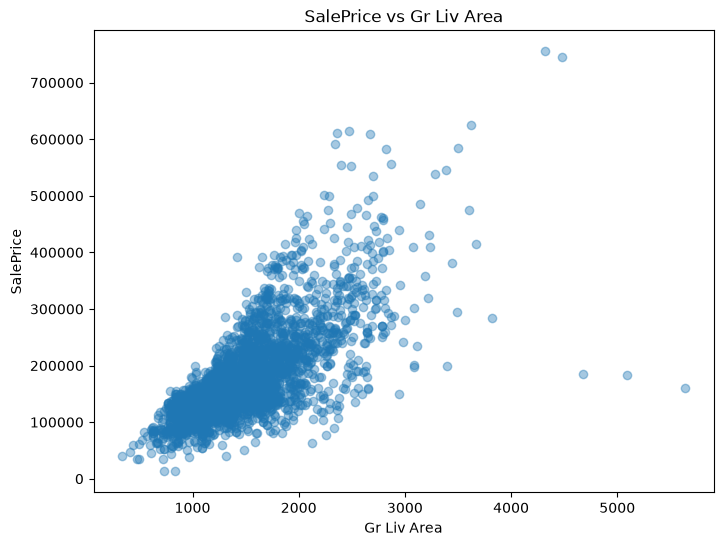

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(housing["Gr Liv Area"], housing["SalePrice"], alpha=0.4)
plt.xlabel("Gr Liv Area")
plt.ylabel("SalePrice")
plt.title("SalePrice vs Gr Liv Area")
plt.show()

2-3 maisons avec une grande surface mais un prix anormalement bas, outliers a garder en tete

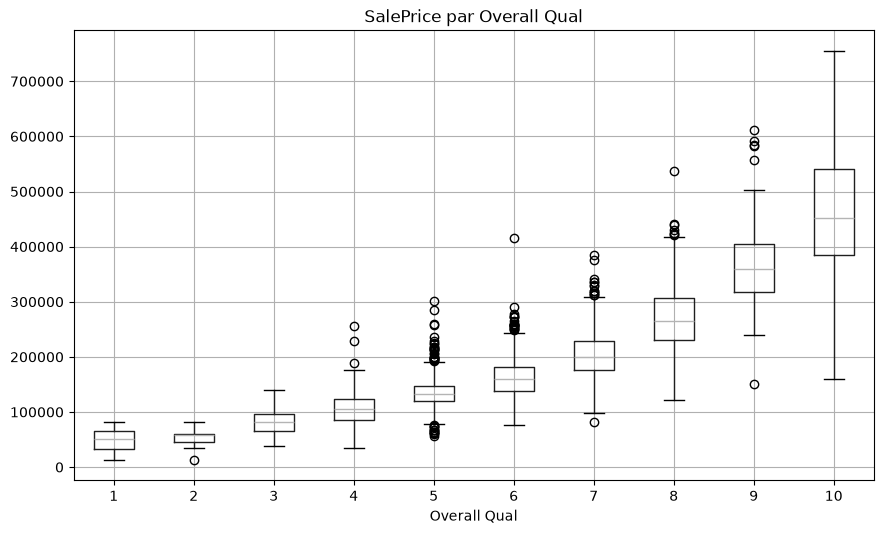

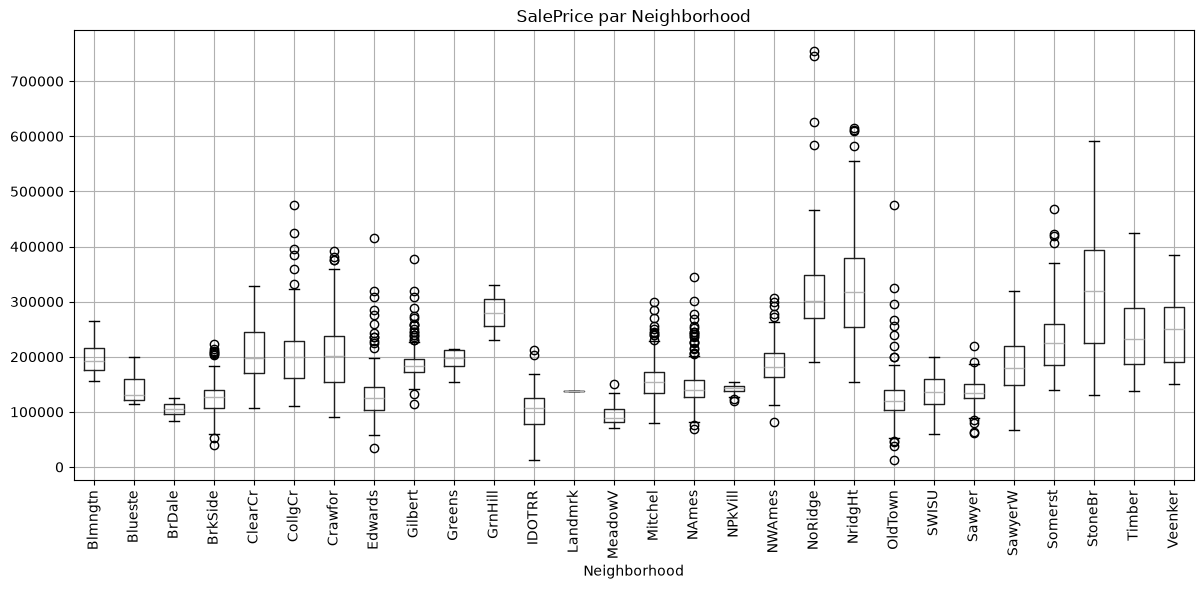

In [11]:
housing.boxplot(column="SalePrice", by="Overall Qual", figsize=(10,6))
plt.title("SalePrice par Overall Qual")
plt.suptitle("")
plt.show()

housing.boxplot(column="SalePrice", by="Neighborhood", figsize=(14,6), rot=90)
plt.title("SalePrice par Neighborhood")
plt.suptitle("")
plt.show()

le prix varie clairement selon la qualite et le quartier, bons candidats comme features

In [12]:
quality = housing["Overall Qual"]
lv_area = housing["Gr Liv Area"]

print(quality.describe())
lv_area.describe()


count    2930.000000
mean        6.094881
std         1.411026
min         1.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        10.000000
Name: Overall Qual, dtype: float64


count    2930.000000
mean     1499.690444
std       505.508887
min       334.000000
25%      1126.000000
50%      1442.000000
75%      1742.750000
max      5642.000000
Name: Gr Liv Area, dtype: float64

In [13]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    housing, 
    test_size=0.2, 
    stratify=housing["Overall Qual"], 
    random_state=42
)

on decoupe notre data set par rapport a l overall quality et on s assure que les proportion sont respecte 

In [14]:
def prop(data, col):
    return (data[col].value_counts() / len(data)).sort_index()

comparison = pd.DataFrame({
    "Overall": prop(housing, "Overall Qual" ),
    "Train": prop(train_set, "Overall Qual"),
    "Test": prop(test_set, "Overall Qual"),
})

comparison

,Overall,Train,Test
Overall Qual,,,
1,0.001365,0.001280,0.001706
2,0.004437,0.004266,0.005119
3,0.013652,0.013652,0.013652
4,0.077133,0.077218,0.076792
5,0.281570,0.281570,0.281570
6,0.249829,0.250000,0.249147
7,0.205461,0.205205,0.206485
8,0.119454,0.119454,0.119454
9,0.036519,0.036689,0.035836


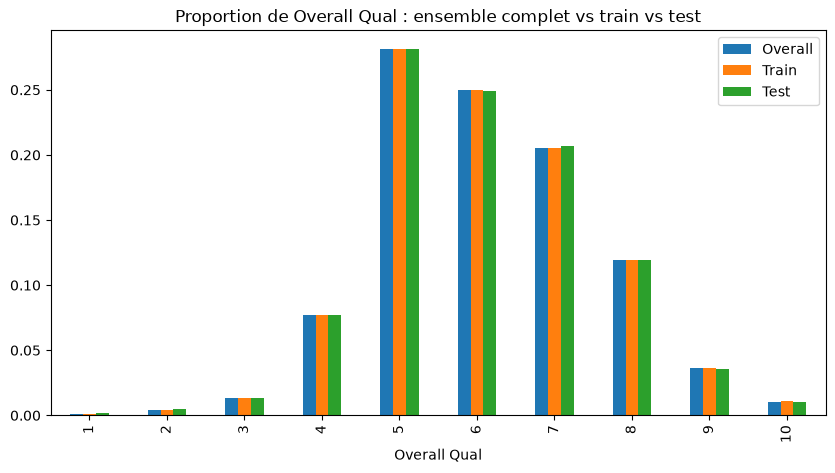

In [15]:
comparison.plot(kind="bar", figsize=(10,5))
plt.title("Proportion de Overall Qual : ensemble complet vs train vs test")
plt.show()

la proportion est respecte entre le test et le train 

STEP 3

In [16]:
X_train = train_set.drop("SalePrice", axis=1)
y_train = train_set["SalePrice"].copy()

X_test = test_set.drop("SalePrice", axis=1)
y_test = test_set["SalePrice"].copy()

On garde uniquement sale price comme valeur a predire

In [17]:
# Inspection rapide (informatif uniquement — remplacé plus tard par num_cols/ordinal_cols/nominal_cat_cols
# une fois l'encodage ordinal effectué)
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold']
Categorical columns: ['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating Q

liste des colonnes numerique et categorielle 

In [18]:
none_means_absent_nominal = [
    "Alley", "Garage Type", "Fence", "Misc Feature"
]

for col in none_means_absent_nominal:
    X_train[col] = X_train[col].fillna("None")
    X_test[col] = X_test[col].fillna("None")

# Mas Vnr Type : "None" seulement si Mas Vnr Area == 0
X_train.loc[X_train["Mas Vnr Area"] == 0, "Mas Vnr Type"] = \
    X_train.loc[X_train["Mas Vnr Area"] == 0, "Mas Vnr Type"].fillna("None")
X_test.loc[X_test["Mas Vnr Area"] == 0, "Mas Vnr Type"] = \
    X_test.loc[X_test["Mas Vnr Area"] == 0, "Mas Vnr Type"].fillna("None")

NaN = absence de la caracteristique (pas de garage, pas de cloture...), remplace par "None" et pas 0

In [19]:
# Garage Yr Blt : pas de garage -> on utilise Year Built comme valeur neutre
X_train["Garage Yr Blt"] = X_train["Garage Yr Blt"].fillna(X_train["Year Built"])
X_test["Garage Yr Blt"] = X_test["Garage Yr Blt"].fillna(X_test["Year Built"])

In [20]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_specs = {
    "Bsmt Qual":      ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Bsmt Cond":      ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Bsmt Exposure":  ["None", "No", "Mn", "Av", "Gd"],
    "BsmtFin Type 1": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFin Type 2": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "Exter Qual":     ["Po", "Fa", "TA", "Gd", "Ex"],
    "Exter Cond":     ["Po", "Fa", "TA", "Gd", "Ex"],
    "Heating QC":     ["Po", "Fa", "TA", "Gd", "Ex"],
    "Kitchen Qual":   ["Po", "Fa", "TA", "Gd", "Ex"],
    "Fireplace Qu":   ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Garage Finish":  ["None", "Unf", "RFn", "Fin"],
    "Garage Qual":    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Garage Cond":    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Pool QC":        ["None", "Fa", "TA", "Gd", "Ex"],
    "Lot Shape":      ["IR3", "IR2", "IR1", "Reg"],
    "Paved Drive":    ["N", "P", "Y"],
    "Functional":     ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "Utilities":      ["NoSeWa", "NoSewr", "AllPub"],
    "Land Slope":     ["Sev", "Mod", "Gtl"],
}

# Colonnes où NaN signifie "absence" -> on remplace par "None" avant l'encodage
ordinal_none_cols = [
    "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2",
    "Fireplace Qu", "Garage Finish", "Garage Qual", "Garage Cond", "Pool QC"
]
for col in ordinal_none_cols:
    X_train[col] = X_train[col].fillna("None")
    X_test[col] = X_test[col].fillna("None")

# Encodage ordinal colonne par colonne (fit sur train, transform sur train+test)
for col, order in ordinal_specs.items():
    enc = OrdinalEncoder(categories=[order])
    X_train[col] = enc.fit_transform(X_train[[col]])
    X_test[col] = enc.transform(X_test[[col]])

ordinal_cols = list(ordinal_specs.keys())

colonnes avec un ordre naturel (Po < Fa < TA < Gd < Ex) encodees en 0,1,2... pour garder cet ordre

In [21]:
# On retire les identifiants qui ne sont pas des features
for id_col in ["Order", "PID"]:
    if id_col in X_train.columns:
        X_train = X_train.drop(columns=[id_col])
        X_test = X_test.drop(columns=[id_col])

# MS SubClass est un code catégoriel, pas une vraie grandeur numérique
X_train["MS SubClass"] = X_train["MS SubClass"].astype(str)
X_test["MS SubClass"] = X_test["MS SubClass"].astype(str)

all_num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
all_cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# Les colonnes ordinales sont déjà numériques après encodage -> à exclure du num_pipeline classique
# (elles n'ont plus besoin d'imputation/scaling au même titre que le reste, mais on peut les garder groupées)
num_cols = [c for c in all_num_cols if c not in ordinal_cols]
nominal_cat_cols = [c for c in all_cat_cols]  # colonnes catégorielles restantes = sans ordre naturel

print(len(num_cols), "colonnes numériques")
print(len(ordinal_cols), "colonnes ordinales (déjà encodées)")
print(len(nominal_cat_cols), "colonnes nominales (à one-hot encoder)")

35 colonnes numériques
19 colonnes ordinales (déjà encodées)
25 colonnes nominales (à one-hot encoder)


separation finale: numerique / ordinal deja encode / categoriel a one-hot encoder

Step 4

In [22]:
correlations = (
    X_train.assign(SalePrice=y_train)
    .corr(numeric_only=True)["SalePrice"]
    .sort_values(ascending=False)
)
correlations

SalePrice          1.000000
Overall Qual       0.799530
Gr Liv Area        0.706943
Exter Qual         0.694727
Kitchen Qual       0.672635
Garage Cars        0.645681
Garage Area        0.643014
Total Bsmt SF      0.627593
1st Flr SF         0.616212
Bsmt Qual          0.601902
Garage Finish      0.556066
Year Built         0.553135
Full Bath          0.550369
Garage Yr Blt      0.536864
Fireplace Qu       0.535070
Year Remod/Add     0.531513
Mas Vnr Area       0.501072
TotRms AbvGrd      0.500044
Fireplaces         0.474321
Heating QC         0.449231
BsmtFin SF 1       0.426911
Bsmt Exposure      0.406918
Lot Frontage       0.368112
BsmtFin Type 1     0.331148
Wood Deck SF       0.321990
Open Porch SF      0.312514
Half Bath          0.285203
2nd Flr SF         0.277929
Paved Drive        0.275557
Garage Qual        0.270910
Bsmt Full Bath     0.263092
Garage Cond        0.260004
Lot Area           0.255607
Bsmt Cond          0.209864
Bsmt Unf SF        0.188083
Bedroom AbvGr      0

In [23]:
# --- Feature engineering (à insérer après le drop low_corr_cols, avant la reconstruction du pipeline) ---

# Surface totale (sous-sol + rez-de-chaussée + étage)
X_train["Total_SF"] = X_train["Total Bsmt SF"] + X_train["1st Flr SF"] + X_train["2nd Flr SF"]
X_test["Total_SF"] = X_test["Total Bsmt SF"] + X_test["1st Flr SF"] + X_test["2nd Flr SF"]

# Âge de la maison au moment de la vente
# (Yr Sold ayant été supprimée car peu corrélée, on la relit depuis train_set/test_set d'origine)
X_train["House_Age"] = train_set.loc[X_train.index, "Yr Sold"] - X_train["Year Built"]
X_test["House_Age"] = test_set.loc[X_test.index, "Yr Sold"] - X_test["Year Built"]

# Nombre total de salles de bain (full + 0.5*half, sous-sol inclus)
X_train["Total_Bath"] = (X_train["Full Bath"] + 0.5*X_train["Half Bath"] +
                          X_train["Bsmt Full Bath"] + 0.5*X_train["Bsmt Half Bath"])
X_test["Total_Bath"] = (X_test["Full Bath"] + 0.5*X_test["Half Bath"] +
                         X_test["Bsmt Full Bath"] + 0.5*X_test["Bsmt Half Bath"])

# Présence d'une piscine (binaire)
X_train["Has_Pool"] = (X_train["Pool Area"] > 0).astype(int)
X_test["Has_Pool"] = (X_test["Pool Area"] > 0).astype(int)

# Vérifier la corrélation des nouvelles features avec le prix
new_features = ["Total_SF", "House_Age", "Total_Bath", "Has_Pool"]
X_train[new_features].assign(SalePrice=y_train).corr()["SalePrice"]

Total_SF      0.795613
House_Age    -0.553314
Total_Bath    0.632031
Has_Pool      0.108512
SalePrice     1.000000
Name: SalePrice, dtype: float64

creation de features combinees (surface totale, age, nb de sdb) + test dune feature piscine (rare, peu utile)

In [24]:
low_corr_cols = ["3Ssn Porch", "Utilities", "Exter Cond", "Mo Sold", 
                  "BsmtFin Type 2", "BsmtFin SF 2", "Misc Val", 
                  "Yr Sold", "Low Qual Fin SF", "Bsmt Half Bath","Land Slope","Pool Area","Screen Porch","Overall Cond"]

X_train = X_train.drop(columns=[c for c in low_corr_cols if c in X_train.columns])
X_test = X_test.drop(columns=[c for c in low_corr_cols if c in X_test.columns])

on retire les colonnes avec une correlation quasi nulle au prix

In [25]:
correlations = (
    X_train.assign(SalePrice=y_train)
    .corr(numeric_only=True)["SalePrice"]
    .sort_values(ascending=False)
)
correlations

SalePrice         1.000000
Overall Qual      0.799530
Total_SF          0.795613
Gr Liv Area       0.706943
Exter Qual        0.694727
Kitchen Qual      0.672635
Garage Cars       0.645681
Garage Area       0.643014
Total_Bath        0.632031
Total Bsmt SF     0.627593
1st Flr SF        0.616212
Bsmt Qual         0.601902
Garage Finish     0.556066
Year Built        0.553135
Full Bath         0.550369
Garage Yr Blt     0.536864
Fireplace Qu      0.535070
Year Remod/Add    0.531513
Mas Vnr Area      0.501072
TotRms AbvGrd     0.500044
Fireplaces        0.474321
Heating QC        0.449231
BsmtFin SF 1      0.426911
Bsmt Exposure     0.406918
Lot Frontage      0.368112
BsmtFin Type 1    0.331148
Wood Deck SF      0.321990
Open Porch SF     0.312514
Half Bath         0.285203
2nd Flr SF        0.277929
Paved Drive       0.275557
Garage Qual       0.270910
Bsmt Full Bath    0.263092
Garage Cond       0.260004
Lot Area          0.255607
Bsmt Cond         0.209864
Bsmt Unf SF       0.188083
B

In [26]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 2344 entries, 1047 to 2822
Data columns (total 69 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MS SubClass     2344 non-null   str    
 1   MS Zoning       2344 non-null   str    
 2   Lot Frontage    1960 non-null   float64
 3   Lot Area        2344 non-null   int64  
 4   Street          2344 non-null   str    
 5   Alley           2344 non-null   str    
 6   Lot Shape       2344 non-null   float64
 7   Land Contour    2344 non-null   str    
 8   Lot Config      2344 non-null   str    
 9   Neighborhood    2344 non-null   str    
 10  Condition 1     2344 non-null   str    
 11  Condition 2     2344 non-null   str    
 12  Bldg Type       2344 non-null   str    
 13  House Style     2344 non-null   str    
 14  Overall Qual    2344 non-null   int64  
 15  Year Built      2344 non-null   int64  
 16  Year Remod/Add  2344 non-null   int64  
 17  Roof Style      2344 non-null   str    
 18  R

In [27]:
print("Colonnes X_train:", X_train.shape[1])
print("Colonnes X_test :", X_test.shape[1])
print("Même colonnes ?", list(X_train.columns) == list(X_test.columns))

Colonnes X_train: 69
Colonnes X_test : 69
Même colonnes ? True


verification technique: aucune colonne perdue ou en trop avant de relancer le pipeline

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [29]:
# 1. Régénérer les listes de colonnes à partir de X_train actuel (post étape 4)
ordinal_cols = [c for c in ordinal_cols if c in X_train.columns]

num_cols = [c for c in X_train.select_dtypes(include=[np.number]).columns if c not in ordinal_cols]
nominal_cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

all_assigned = set(num_cols) | set(ordinal_cols) | set(nominal_cat_cols)
print("Assignées mais absentes de X_train :", all_assigned - set(X_train.columns))
print("Dans X_train mais non assignées     :", set(X_train.columns) - all_assigned)

# 2. Redéfinir les 3 pipelines de preprocessing
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# 3. Recréer le ColumnTransformer avec les nouvelles listes
preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("ord", ordinal_pipeline, ordinal_cols),
    ("nom", nominal_pipeline, nominal_cat_cols)
])

# 4. Relancer fit_transform / transform
X_train_prepared = preprocessing.fit_transform(X_train)
X_test_prepared = preprocessing.transform(X_test)

arr = X_train_prepared.toarray() if hasattr(X_train_prepared, "toarray") else X_train_prepared
print("NaN restants :", np.isnan(arr).sum())
print("Shape train:", X_train_prepared.shape, "| Shape test:", X_test_prepared.shape)

Assignées mais absentes de X_train : set()
Dans X_train mais non assignées     : set()
NaN restants : 0
Shape train: (2344, 239) | Shape test: (586, 239)


preprocessing final: imputation, scaling et one-hot appliques, appris sur train seulement

Step 5 

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [31]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_prepared, y_train)

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train_prepared, y_train)

forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train_prepared, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

les 3 modeles sont entraines sur les memes donnees preparees, pour rester comparables

In [32]:
for name, model in [("Linear Regression", lin_reg), 
                     ("Decision Tree", tree_reg), 
                     ("Random Forest", forest_reg)]:
    preds = model.predict(X_train_prepared)
    print(f"{name} — quelques prédictions vs réel :")
    print("Prédictions :", preds[:5].round(0))
    print("Réel        :", y_train[:5].values)
    print()

Linear Regression — quelques prédictions vs réel :
Prédictions : [141057. 141598. 151683. 190222. 176398.]
Réel        : [143000 155000 147000 190000 200000]

Decision Tree — quelques prédictions vs réel :
Prédictions : [143000. 155000. 147000. 190000. 200000.]
Réel        : [143000 155000 147000 190000 200000]

Random Forest — quelques prédictions vs réel :
Prédictions : [145366. 150024. 142140. 189690. 197955.]
Réel        : [143000 155000 147000 190000 200000]



In [33]:
from sklearn.metrics import mean_squared_error

for name, model in [("Linear Regression", lin_reg), 
                     ("Decision Tree", tree_reg), 
                     ("Random Forest", forest_reg)]:
    preds_train = model.predict(X_train_prepared)
    rmse_train = mean_squared_error(y_train, preds_train) ** 0.5
    print(f"{name} — RMSE sur le TRAIN : {rmse_train:,.0f}")

Linear Regression — RMSE sur le TRAIN : 22,893
Decision Tree — RMSE sur le TRAIN : 110
Random Forest — RMSE sur le TRAIN : 9,611


premier apercu sur le train, juste pour verifier que les modeles ont bien appris quelque chose

In [34]:
from sklearn.metrics import mean_squared_error, r2_score

results = []

for name, model in [("Linear Regression", lin_reg), 
                     ("Decision Tree", tree_reg), 
                     ("Random Forest", forest_reg)]:
    preds_test = model.predict(X_test_prepared)
    
    rmse = mean_squared_error(y_test, preds_test) ** 0.5
    r2 = r2_score(y_test, preds_test)
    
    results.append({"Model": name, "Test RMSE": rmse, "Test R²": r2})

results_df = pd.DataFrame(results)
results_df

,Model,Test RMSE,Test R²
0,Linear Regression,32149.404338,0.845132
1,Decision Tree,34205.883287,0.824686
2,Random Forest,24568.352193,0.909559


In [35]:
results_df_display = results_df.copy()
results_df_display["Test RMSE"] = results_df_display["Test RMSE"].round(0).map("{:,.0f}".format)
results_df_display["Test R²"] = results_df_display["Test R²"].round(3)
results_df_display

,Model,Test RMSE,Test R²
0,Linear Regression,"32,149",0.845
1,Decision Tree,"34,206",0.825
2,Random Forest,"24,568",0.910


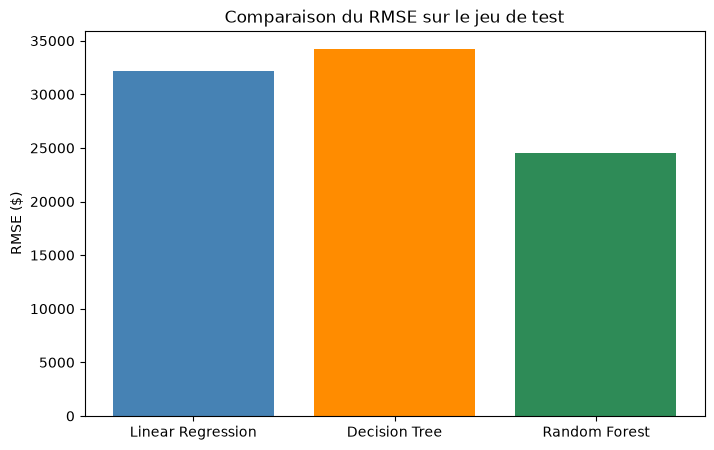

In [36]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Test RMSE"], color=["steelblue", "darkorange", "seagreen"])
plt.title("Comparaison du RMSE sur le jeu de test")
plt.ylabel("RMSE ($)")
plt.show()

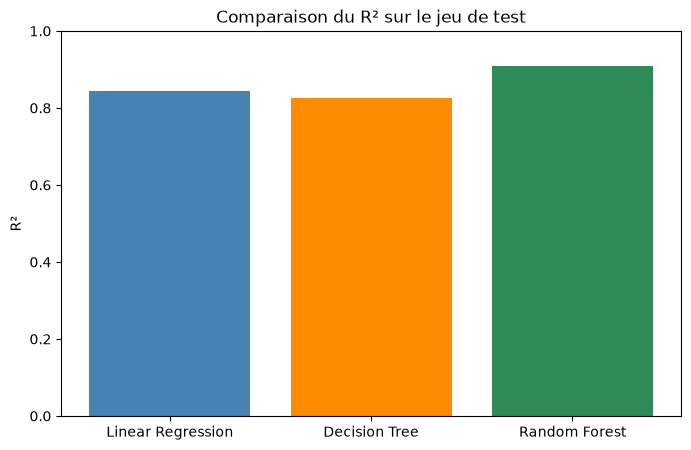

In [37]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Test R²"], color=["steelblue", "darkorange", "seagreen"])
plt.title("Comparaison du R² sur le jeu de test")
plt.ylabel("R²")
plt.ylim(0, 1)
plt.show()

Random Forest a le meilleur score sur le test (RMSE le plus bas, R2 le plus haut)

In [38]:
comparison_overfit = []
for name, model in [("Linear Regression", lin_reg), 
                     ("Decision Tree", tree_reg), 
                     ("Random Forest", forest_reg)]:
    rmse_train = mean_squared_error(y_train, model.predict(X_train_prepared)) ** 0.5
    rmse_test = mean_squared_error(y_test, model.predict(X_test_prepared)) ** 0.5
    comparison_overfit.append({"Model": name, "RMSE Train": rmse_train, "RMSE Test": rmse_test})

pd.DataFrame(comparison_overfit)

,Model,RMSE Train,RMSE Test
0,Linear Regression,22893.024097,32149.404338
1,Decision Tree,109.619779,34205.883287
2,Random Forest,9611.266624,24568.352193


le Decision Tree surapprend clairement: presque 0 erreur sur le train mais bien plus sur le test